In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

def target_function(x):

    m = nn.ReLU()
        
    return m(x)#torch.sigmoid(5*x)

def mse_loss(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_na=200.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

v_min = -1.5
v_max = 1.5

N = 500
input_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

# --- Number of control electrodes (Normally input dim of SM minus 1) --- #
d = model.layer_dims[0] - 1
pbounds = {
    f'x{i}': (v_min, v_max) for i in range(d) 
}

input_idx = 0
target = target_function(input_range)

def f(**kwargs):

    cv_list = list(kwargs.values())
    cv_t = torch.tensor(cv_list, dtype=torch.float32).expand(N, -1)
    cv_t_l = cv_t[:, :input_idx]
    cv_t_r = cv_t[:, input_idx:]

    input_tensor = torch.cat([cv_t_l, input_range, cv_t_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor)

    I_mu = y_out[..., 0].unsqueeze(-1)

    loss = mse_loss(I_mu, target)

    return -loss

In [11]:
optimizer = BayesianOptimization(
    f=f,
    pbounds=pbounds,
    verbose=1,
    random_state=np.random.randint(0, 2**31 - 1),
)
optimizer.maximize(
    init_points=10,
    n_iter=200,
)

|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |
-------------------------------------------------------------------------------------------------
| 2         | -0.104110 | -0.696647 | 0.7553888 | -1.201101 | 0.1113108 | 1.4075969 | -0.004122 |
| 13        | -0.082080 | -1.5      | 1.4934253 | -1.5      | 1.0182586 | 1.5       | 0.1859196 |
| 27        | -0.075959 | -1.5      | -1.227240 | 1.5       | -1.5      | -1.5      | -1.5      |
| 28        | -0.030516 | -1.5      | -1.5      | 1.5       | -1.370234 | -1.5      | -0.191591 |
| 29        | -0.013697 | -1.5      | -1.5      | 0.2597929 | -1.5      | -1.5      | -0.677065 |
| 39        | -0.013624 | -1.5      | -1.5      | -1.5      | -1.5      | -1.5      | -1.5      |
| 54        | -0.010526 | -1.5      | -0.879185 | -1.5      | 0.1620922 | -1.5      | -1.5      |


In [4]:
opt_vals = list(optimizer.max['params'].values())
print(np.array(opt_vals).tolist())

y_out = forward_whole_range(model, opt_vals, input_idx, v_min, v_max, N)
y_out = y_out[..., 0].reshape(-1, 1)

y_sc = normalize_over_range(y_out)
t_sc = normalize_over_range(target)

data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/relu/sim_0.npz")
I_sc = normalize_over_range(data['current'] / 1.602176634e-19)

#plt.plot(np.linspace(v_min, v_max, 50), I_sc, label='simulation')
plt.plot(input_range, y_sc, label='sm')
plt.plot(input_range, t_sc, label='target')

plt.legend()

NameError: name 'optimizer' is not defined

In [29]:
def multiple_runs(num_runs, num_iter=100):
    opt_param_list = []
    target_list = []
    for i in range(num_runs):
        optimizer = BayesianOptimization(
            f=f,
            pbounds=pbounds,
            verbose=0,
            random_state=i,
        )
        optimizer.maximize(
            init_points=10,
            n_iter=10,
        )
        opt_param_list.append(np.array(list(optimizer.max['params'].values())).tolist())
        target_list.append(float(optimizer.max['target']))
        
        print(f'{i+1}/{num_runs} | Params: {opt_param_list[i]}')
    
    opt_param_arr = np.stack(opt_param_list)
    target_arr = np.stack(target_list)

    return opt_param_arr, target_arr

params, targets = multiple_runs(num_runs=5, num_iter=100)

1/5 | Params: [-1.5, -1.5, -0.40974578702232173, -1.5, -0.5062652929107605, 0.7130867756290937]
2/5 | Params: [-0.6366739842409538, -1.109914283645167, -1.4418991263891088, 0.5365065988196731, -0.8651156519998229, -0.7033600218833214]
3/5 | Params: [-1.1185200848961676, 0.29023592693578726, -0.8219639981872924, -1.179162947070051, -0.8390813787883209, -0.4505211449901023]
4/5 | Params: [-1.5, -1.3002610332001303, -1.5, 0.4075340474560323, -0.28931030156055365, -0.8447258467804718]
5/5 | Params: [1.5, 1.4688753531823546, 0.9493433290511059, 1.5, 1.5, -1.3473200254669648]


best loss: -0.03743092343211174
Total points: 500  Near-optimal: 500


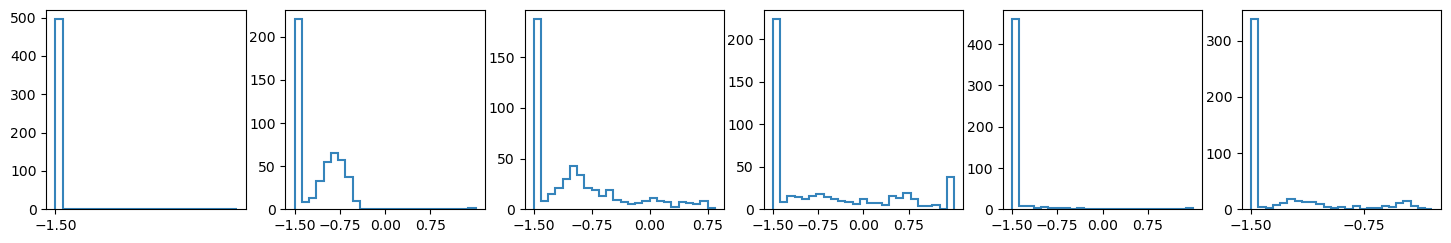

In [102]:
out = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_relu_run_0.npy', allow_pickle=True)
data = out.item()
X = data['params']
t = data['targets']

best_loss = t.min()
print(f'best loss: {best_loss}')

margin = 1.5
loss_th = best_loss + margin

mask = t <= loss_th
X_good = X[mask]
t_good = t[mask]
print("Total points:", len(t), " Near-optimal:", len(t_good))

x_ticks= np.arange(-1.5, 1.5, 0.75)

fig, ax = plt.subplots(ncols=d, figsize=(3*d, 3))

for a in ax:
    a.set_box_aspect(1)
    a.set_xticks(x_ticks)

for i in range(d):
    ax[i].hist(X_good[:, i], bins=25, histtype='step', lw=1.5, alpha=.9)

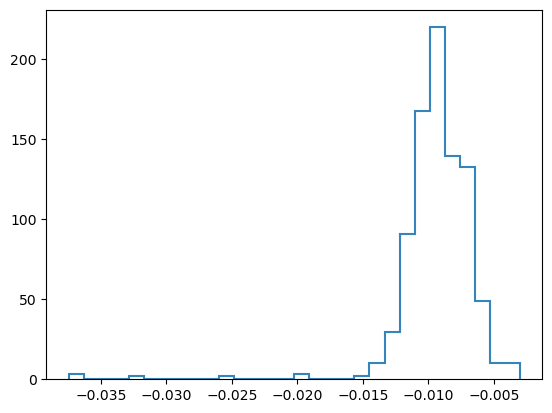

In [95]:
plt.hist(t, bins=30, density=True, histtype='step', lw=1.5, alpha=.9)
plt.show()

In [103]:
from sklearn.cluster import KMeans, DBSCAN

kmeans = KMeans(n_clusters=6, random_state=0, n_init='auto').fit(X)
dbscan = DBSCAN(eps=0.4, min_samples=2).fit(X)

labels_kmeans = kmeans.labels_
labels_dbscan = dbscan.labels_

unique_labels_kmeans = set(labels_kmeans)
unique_labels_dbscan = set(labels_dbscan)

if -1 in unique_labels_dbscan:
    unique_labels_dbscan.remove(-1)

M_kmeans = len(unique_labels_kmeans)
M_dbscan = len(unique_labels_dbscan)
print(f'Multiplicity kmeans: {M_kmeans}')
print(f'Multiplicity dbscan: {M_dbscan}')

from collections import defaultdict

kmeans_clusters = defaultdict(list)
for V, label in zip(X, labels_kmeans):
    if label == -1:
        continue
    kmeans_clusters[label].append(V)
    
for label, points in kmeans_clusters.items():
    pts = np.array(points)
    center = pts.mean(axis=0)
    # cluster "diameter" (max distance between any two points)
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    diameter = dists.max()
    print(f"Cluster {label}: n={len(pts)}, diameter={diameter}")

dbscan_clusters = defaultdict(list)
for V, label in zip(X, labels_dbscan):
    if label == -1:
        continue
    dbscan_clusters[label].append(V)
    
for label, points in dbscan_clusters.items():
    pts = np.array(points)
    center = pts.mean(axis=0)
    # cluster "diameter" (max distance between any two points)
    dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    diameter = dists.max()
    print(f"Cluster {label}: n={len(pts)}, diameter={diameter}")

Multiplicity kmeans: 6
Multiplicity dbscan: 9
Cluster 1: n=198, diameter=3.3120956748251955
Cluster 5: n=90, diameter=1.5256360940061873
Cluster 3: n=78, diameter=1.4367212082148095
Cluster 4: n=29, diameter=1.7045262780556774
Cluster 0: n=101, diameter=2.325320499591728
Cluster 2: n=4, diameter=3.5092866252039387
Cluster 0: n=432, diameter=3.9147635213198213
Cluster 1: n=3, diameter=0.3808293896531574
Cluster 2: n=13, diameter=0.3715747846328968
Cluster 3: n=22, diameter=0.9514973535504421
Cluster 4: n=2, diameter=0.3130256330635364
Cluster 5: n=3, diameter=0.13564447100046256
Cluster 6: n=3, diameter=0.18562043803182593
Cluster 7: n=2, diameter=0.3420305011787101
Cluster 8: n=2, diameter=0.2263901088710981


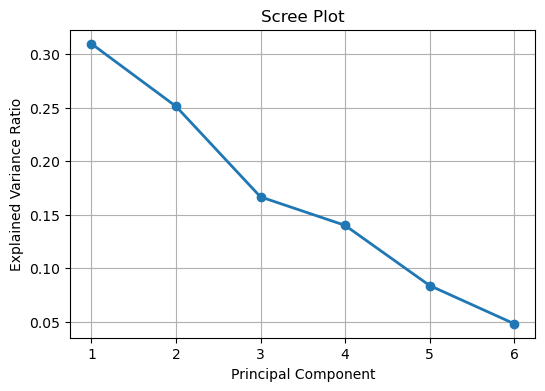

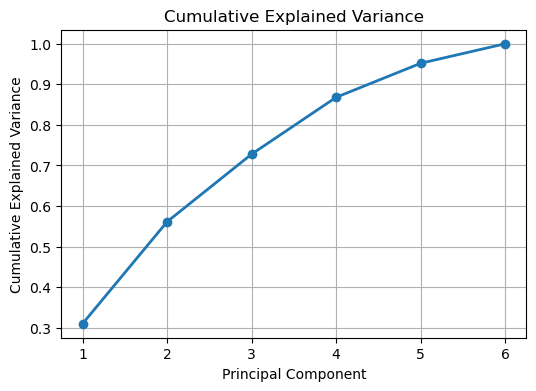

In [128]:
# Fit PCA with all components
pca = PCA()
pca.fit(X_good_scaled)

# Explained variance ratio per component
evr = pca.explained_variance_ratio_
components = np.arange(1, len(evr) + 1)

# Scree plot (per-component)
plt.figure(figsize=(6,4))
plt.plot(components, evr, 'o-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

# (Optional) cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(components, np.cumsum(evr), 'o-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.show()

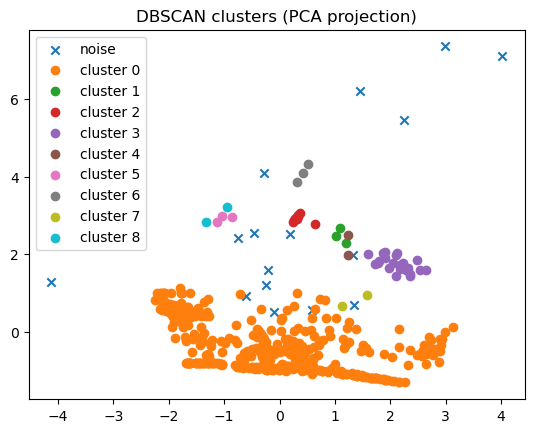

In [127]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

X_good_scaled = (X_good - X_good_mean) / (X_good_std + 1e-6)
#print(X_good_scaled)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_good_scaled)

plt.figure()
for lab in np.unique(labels_dbscan):
    mask = labels_dbscan == lab
    if lab == -1:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], marker='x', label='noise')
    else:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f'cluster {lab}')
plt.legend()
plt.title("DBSCAN clusters (PCA projection)")

plt.show()